In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
rc('text', usetex=False)

import scipy.io as sio
from joblib import Parallel, delayed

import sys
import os
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)
    
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")
    
from utils import *

# az.style.use("arviz-doc")
plt.rcParams['figure.dpi'] = 140
from matplotlib import rc

rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
rc('text', usetex=False)

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
labels = ["Low coherence", "High coherence", "Divided attention", "Focused attention", "Unexpected", "Expected"]
colors = ["gray", "darkgray", "blue", "darkblue", "red", "darkred"]
linestyles = ["--", "-", "--", "-", "--", "-"]

xaxis = np.array(range(-250, 750, 1))*(1000/120)
start_idx, end_idx = np.searchsorted(xaxis, -500), np.searchsorted(xaxis, 1500)
(start_idx, end_idx)

(np.int64(191), np.int64(430))

In [3]:
# Masks
low_coherence_mask = r_table["coh"] == "low"
high_coherence_mask = r_table["coh"] == "high"

divided_attention_mask = r_table["att"] == "divided"
focused_attention_mask = r_table["att"] == "focused"

unexpected_mask = r_table["exp_al"] == "unexpected"
expected_mask = r_table["exp_al"] == "expected"

In [4]:
d_low = cd.reshape(-1, 1000)[low_coherence_mask]
d_high = cd.reshape(-1, 1000)[high_coherence_mask]

d_divided = cd.reshape(-1, 1000)[divided_attention_mask]
d_focused = cd.reshape(-1, 1000)[focused_attention_mask]

d_unexpected = cd.reshape(-1, 1000)[unexpected_mask]
d_expected = cd.reshape(-1, 1000)[expected_mask]


e_low = e.reshape(-1, 1000)[low_coherence_mask]
e_high = e.reshape(-1, 1000)[high_coherence_mask]

e_divided = e.reshape(-1, 1000)[divided_attention_mask]
e_focused = e.reshape(-1, 1000)[focused_attention_mask]

e_unexpected = e.reshape(-1, 1000)[unexpected_mask]
e_expected = e.reshape(-1, 1000)[expected_mask]

In [5]:
d_high.shape, d_low.shape, d_divided.shape, d_focused.shape, e_expected.shape, e_unexpected.shape

((17280, 1000),
 (17280, 1000),
 (17280, 1000),
 (17280, 1000),
 (21120, 1000),
 (7680, 1000))

In [6]:
unsersample_mask = np.random.choice(np.arange(0, 21120), 7680, replace=False)
d_expected = d_expected[unsersample_mask]
e_expected = e_expected[unsersample_mask]

d_expected.shape, e_expected.shape

((7680, 1000), (7680, 1000))

In [7]:
nboot = 1000
CI_int = (2.5, 97.5)
random_seed = 42

# d differences:
# Coherence: high vs. low
_, _, diff_CI_coh, _ = fnc_time_bootstrap_optimized(
    d_high, d_low, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
# Attention: focused vs. divided
_, _, diff_CI_att, _ = fnc_time_bootstrap_optimized(
    d_focused, d_divided, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
# Expectation: expected vs. unexpected
_, _, diff_CI_exp, _ = fnc_time_bootstrap_optimized(
    d_expected, d_unexpected, nboot, CI_int, n_jobs=-1, random_seed=random_seed)

# # e differences:
_, _, diff_CI_coh_e, _ = fnc_time_bootstrap_optimized(
    e_high, e_low, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
_, _, diff_CI_att_e, _ = fnc_time_bootstrap_optimized(
    e_focused, e_divided, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
_, _, diff_CI_exp_e, _ = fnc_time_bootstrap_optimized(
    e_expected, e_unexpected, nboot, CI_int, n_jobs=-1, random_seed=random_seed)


/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWa

In [8]:
import scipy.stats as stats

/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


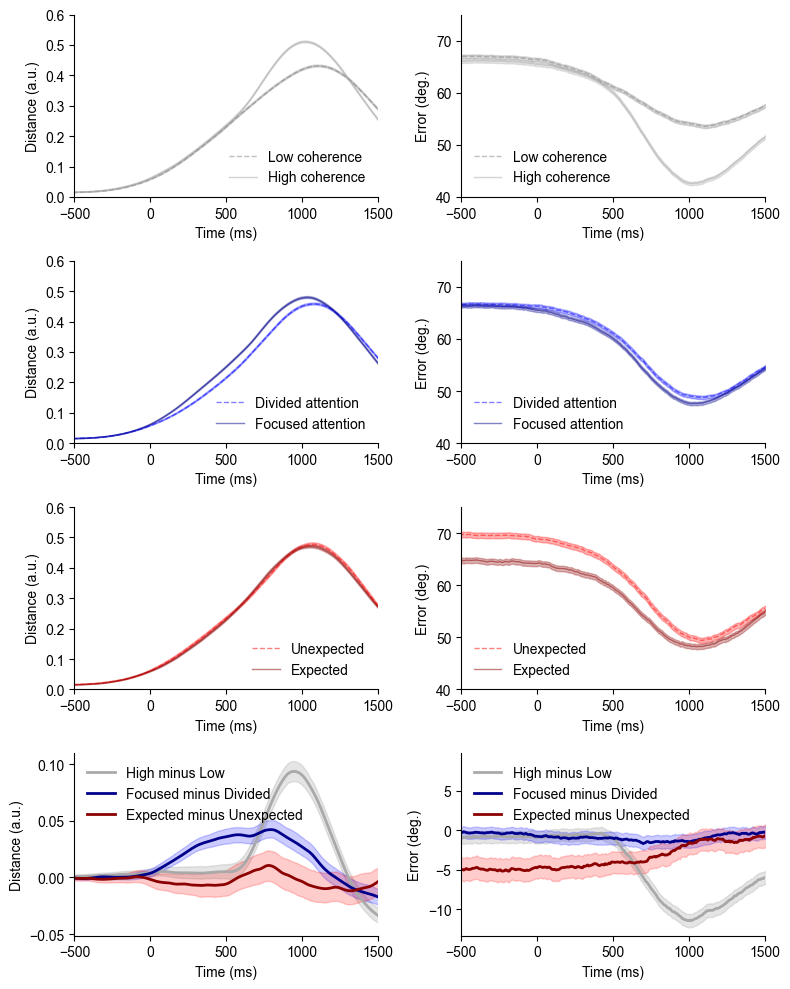

In [9]:
# Plotting the data
fig, ax = plt.subplots(4,2, figsize=(4*2, 10), dpi=100, sharex=False)

d_ax = ax[:3,0]
e_ax = ax[:3,1]

vals = [d_low, d_high, d_divided, d_focused, d_unexpected, d_expected]

# for i in range(6):
#     d_ax[i//2].plot(xaxis, np.nanmean(vals[i], axis=0), linestyle=linestyles[i], label=labels[i], color=colors[i], alpha=0.5, linewidth=4)
#     d_ax[i//2].set_xlim(-500, 1500)
#     d_ax[i//2].set_ylim(0, 0.6)
#     d_ax[i//2].legend( loc='lower right', frameon=False)
#     d_ax[i//2].set_xlabel("Time (ms)")
#     d_ax[i//2].set_ylabel("Distance (a.u.)")

for i in range(6):
    mean_val = np.nanmean(vals[i], axis=0)
    sem_val = np.nanstd(vals[i], axis=0) / np.sqrt(vals[i].shape[0])
    ax_current = d_ax[i//2]
    
    ax_current.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                    color=colors[i], alpha=0.5, linewidth=1)
    ax_current.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                            color=colors[i], alpha=0.3)
    ax_current.set_xlim(-500, 1500)
    ax_current.set_ylim(0, 0.6)
    ax_current.legend(loc='lower right', frameon=False)
    ax_current.set_xlabel("Time (ms)")
    ax_current.set_ylabel("Distance (a.u.)")
    # Hide top and right spines
    ax_current.spines['top'].set_visible(False)
    ax_current.spines['right'].set_visible(False)

vals = [e_low, e_high, e_divided, e_focused, e_unexpected, e_expected]

# for i in range(6):
#     e_ax[i//2].plot(xaxis, np.nanmean(vals[i], axis=0), linestyle=linestyles[i], label=labels[i], color=colors[i], alpha=0.5, linewidth=4)
#     e_ax[i//2].set_xlim(-500, 1500)
#     e_ax[i//2].set_ylim(40, 75)
#     e_ax[i//2].legend( loc='lower left', frameon=False)
#     e_ax[i//2].set_xlabel("Time (ms)")
#     e_ax[i//2].set_ylabel("Error (deg.)")
    
for i in range(6):
    mean_val = np.nanmean(vals[i], axis=0)
    sem_val = np.nanstd(vals[i], axis=0) / np.sqrt(vals[i].shape[0])
    ax_current = e_ax[i//2]
    
    ax_current.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                    color=colors[i], alpha=0.5, linewidth=1)
    ax_current.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                            color=colors[i], alpha=0.3)
    ax_current.set_xlim(-500, 1500)
    ax_current.set_ylim(40, 75)
    ax_current.legend(loc='lower left', frameon=False)
    ax_current.set_xlabel("Time (ms)")
    ax_current.set_ylabel("Error (deg.)")
    ax_current.spines['top'].set_visible(False)
    ax_current.spines['right'].set_visible(False)

alpha = 0.2

# Plot d differences:
ax[3, 0].plot(xaxis, d_high.mean(axis=0) - d_low.mean(axis=0), label='High minus Low', color='darkgray', linewidth=2)
ax[3, 0].fill_between(xaxis, diff_CI_coh[:, 0], diff_CI_coh[:, 1], color='gray', alpha=alpha)
ax[3, 0].plot(xaxis, d_focused.mean(axis=0) - d_divided.mean(axis=0), label='Focused minus Divided', color='darkblue', linewidth=2)
ax[3, 0].fill_between(xaxis, diff_CI_att[:, 0], diff_CI_att[:, 1], color='blue', alpha=alpha)
ax[3, 0].plot(xaxis, d_expected.mean(axis=0) - d_unexpected.mean(axis=0), label='Expected minus Unexpected', color='darkred', linewidth=2)
ax[3, 0].fill_between(xaxis, diff_CI_exp[:, 0], diff_CI_exp[:, 1], color='red', alpha=alpha)
# ax[3, 0].set_title('Differences in d')
ax[3, 0].set_xlim(-500, 1500)
ax[3, 0].set_xlabel('Time (ms)')
ax[3, 0].set_ylabel('Distance (a.u.)')
ax[3, 0].legend( loc='upper left', frameon=False)
ax[3, 0].spines['top'].set_visible(False)
ax[3, 0].spines['right'].set_visible(False)

# Plot e differences:
ax[3, 1].plot(xaxis, e_high.mean(axis=0) - e_low.mean(axis=0), label='High minus Low', color='darkgray', linewidth=2)
ax[3, 1].fill_between(xaxis, diff_CI_coh_e[:, 0], diff_CI_coh_e[:, 1], color='gray', alpha=alpha)
ax[3, 1].plot(xaxis, e_focused.mean(axis=0) - e_divided.mean(axis=0), label='Focused minus Divided', color='darkblue', linewidth=2)
ax[3, 1].fill_between(xaxis, diff_CI_att_e[:, 0], diff_CI_att_e[:, 1], color='blue', alpha=alpha)
ax[3, 1].plot(xaxis, e_expected.mean(axis=0) - e_unexpected.mean(axis=0), label='Expected minus Unexpected', color='darkred', linewidth=2)
ax[3, 1].fill_between(xaxis, diff_CI_exp_e[:, 0], diff_CI_exp_e[:, 1], color='red', alpha=alpha)
# ax[3, 1].set_title('Differences in e')
ax[3, 1].set_xlim(-500, 1500)
ax[3, 1].set_xlabel('Time (ms)')
ax[3, 1].set_ylabel('Error (deg.)')
ax[3, 1].legend( loc='upper left', frameon=False)
ax[3, 1].spines['top'].set_visible(False)
ax[3, 1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


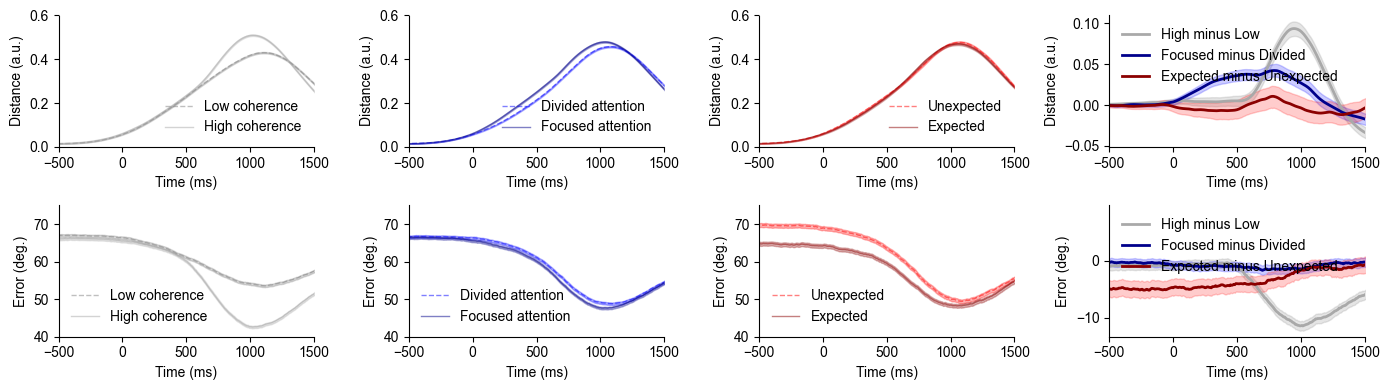

In [10]:
fig, ax = plt.subplots(2, 4, figsize=(14, 4), dpi=100, sharex=False)
# Create a 2-row x 4-column figure

alpha = 0.2  # For the fill transparency in difference plots

# ----- Top Row: Distance (d) Plots -----

# Define the d conditions in the same order as before:
# [0] d_low, [1] d_high, [2] d_divided, [3] d_focused, [4] d_unexpected, [5] d_expected
vals_d = [d_low, d_high, d_divided, d_focused, d_unexpected, d_expected]

# 1. Coherence: Plot d_low and d_high on ax[0,0]
ax_d_coh = ax[0, 0]
for i in [0, 1]:
    mean_val = np.nanmean(vals_d[i], axis=0)
    sem_val = np.nanstd(vals_d[i], axis=0) / np.sqrt(vals_d[i].shape[0])
    ax_d_coh.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_d_coh.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_d_coh.set_xlim(-500, 1500)
ax_d_coh.set_ylim(0, 0.6)
ax_d_coh.set_xlabel("Time (ms)")
ax_d_coh.set_ylabel("Distance (a.u.)")
ax_d_coh.legend(loc='lower right', frameon=False)
ax_d_coh.spines['top'].set_visible(False)
ax_d_coh.spines['right'].set_visible(False)

# 2. Attention: Plot d_divided and d_focused on ax[0,1]
ax_d_att = ax[0, 1]
for i in [2, 3]:
    mean_val = np.nanmean(vals_d[i], axis=0)
    sem_val = np.nanstd(vals_d[i], axis=0) / np.sqrt(vals_d[i].shape[0])
    ax_d_att.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_d_att.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_d_att.set_xlim(-500, 1500)
ax_d_att.set_ylim(0, 0.6)
ax_d_att.set_xlabel("Time (ms)")
ax_d_att.set_ylabel("Distance (a.u.)")
ax_d_att.legend(loc='lower right', frameon=False)
ax_d_att.spines['top'].set_visible(False)
ax_d_att.spines['right'].set_visible(False)

# 3. Expectation: Plot d_unexpected and d_expected on ax[0,2]
ax_d_exp = ax[0, 2]
for i in [4, 5]:
    mean_val = np.nanmean(vals_d[i], axis=0)
    sem_val = np.nanstd(vals_d[i], axis=0) / np.sqrt(vals_d[i].shape[0])
    ax_d_exp.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_d_exp.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_d_exp.set_xlim(-500, 1500)
ax_d_exp.set_ylim(0, 0.6)
ax_d_exp.set_xlabel("Time (ms)")
ax_d_exp.set_ylabel("Distance (a.u.)")
ax_d_exp.legend(loc='lower right', frameon=False)
ax_d_exp.spines['top'].set_visible(False)
ax_d_exp.spines['right'].set_visible(False)

# 4. Differences for d on ax[0,3]
ax_d_diff = ax[0, 3]
# Coherence difference
ax_d_diff.plot(xaxis, d_high.mean(axis=0) - d_low.mean(axis=0),
               label='High minus Low', color='darkgray', linewidth=2)
ax_d_diff.fill_between(xaxis, diff_CI_coh[:, 0], diff_CI_coh[:, 1],
                       color='gray', alpha=alpha)
# Attention difference
ax_d_diff.plot(xaxis, d_focused.mean(axis=0) - d_divided.mean(axis=0),
               label='Focused minus Divided', color='darkblue', linewidth=2)
ax_d_diff.fill_between(xaxis, diff_CI_att[:, 0], diff_CI_att[:, 1],
                       color='blue', alpha=alpha)
# Expectation difference
ax_d_diff.plot(xaxis, d_expected.mean(axis=0) - d_unexpected.mean(axis=0),
               label='Expected minus Unexpected', color='darkred', linewidth=2)
ax_d_diff.fill_between(xaxis, diff_CI_exp[:, 0], diff_CI_exp[:, 1],
                       color='red', alpha=alpha)
ax_d_diff.set_xlim(-500, 1500)
ax_d_diff.set_xlabel("Time (ms)")
ax_d_diff.set_ylabel("Distance (a.u.)")
ax_d_diff.legend(loc='upper left', frameon=False)
ax_d_diff.spines['top'].set_visible(False)
ax_d_diff.spines['right'].set_visible(False)

# ----- Bottom Row: Error (e) Plots -----

# Define the e conditions:
vals_e = [e_low, e_high, e_divided, e_focused, e_unexpected, e_expected]

# 1. Coherence: Plot e_low and e_high on ax[1,0]
ax_e_coh = ax[1, 0]
for i in [0, 1]:
    mean_val = np.nanmean(vals_e[i], axis=0)
    sem_val = np.nanstd(vals_e[i], axis=0) / np.sqrt(vals_e[i].shape[0])
    ax_e_coh.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_e_coh.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_e_coh.set_xlim(-500, 1500)
ax_e_coh.set_ylim(40, 75)
ax_e_coh.set_xlabel("Time (ms)")
ax_e_coh.set_ylabel("Error (deg.)")
ax_e_coh.legend(loc='lower left', frameon=False)
ax_e_coh.spines['top'].set_visible(False)
ax_e_coh.spines['right'].set_visible(False)

# 2. Attention: Plot e_divided and e_focused on ax[1,1]
ax_e_att = ax[1, 1]
for i in [2, 3]:
    mean_val = np.nanmean(vals_e[i], axis=0)
    sem_val = np.nanstd(vals_e[i], axis=0) / np.sqrt(vals_e[i].shape[0])
    ax_e_att.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_e_att.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_e_att.set_xlim(-500, 1500)
ax_e_att.set_ylim(40, 75)
ax_e_att.set_xlabel("Time (ms)")
ax_e_att.set_ylabel("Error (deg.)")
ax_e_att.legend(loc='lower left', frameon=False)
ax_e_att.spines['top'].set_visible(False)
ax_e_att.spines['right'].set_visible(False)

# 3. Expectation: Plot e_unexpected and e_expected on ax[1,2]
ax_e_exp = ax[1, 2]
for i in [4, 5]:
    mean_val = np.nanmean(vals_e[i], axis=0)
    sem_val = np.nanstd(vals_e[i], axis=0) / np.sqrt(vals_e[i].shape[0])
    ax_e_exp.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_e_exp.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_e_exp.set_xlim(-500, 1500)
ax_e_exp.set_ylim(40, 75)
ax_e_exp.set_xlabel("Time (ms)")
ax_e_exp.set_ylabel("Error (deg.)")
ax_e_exp.legend(loc='lower left', frameon=False)
ax_e_exp.spines['top'].set_visible(False)
ax_e_exp.spines['right'].set_visible(False)

# 4. Differences for e on ax[1,3]
ax_e_diff = ax[1, 3]
# Coherence difference
ax_e_diff.plot(xaxis, e_high.mean(axis=0) - e_low.mean(axis=0),
               label='High minus Low', color='darkgray', linewidth=2)
ax_e_diff.fill_between(xaxis, diff_CI_coh_e[:, 0], diff_CI_coh_e[:, 1],
                       color='gray', alpha=alpha)
# Attention difference
ax_e_diff.plot(xaxis, e_focused.mean(axis=0) - e_divided.mean(axis=0),
               label='Focused minus Divided', color='darkblue', linewidth=2)
ax_e_diff.fill_between(xaxis, diff_CI_att_e[:, 0], diff_CI_att_e[:, 1],
                       color='blue', alpha=alpha)
# Expectation difference
ax_e_diff.plot(xaxis, e_expected.mean(axis=0) - e_unexpected.mean(axis=0),
               label='Expected minus Unexpected', color='darkred', linewidth=2)
ax_e_diff.fill_between(xaxis, diff_CI_exp_e[:, 0], diff_CI_exp_e[:, 1],
                       color='red', alpha=alpha)
ax_e_diff.set_xlim(-500, 1500)
ax_e_diff.set_xlabel("Time (ms)")
ax_e_diff.set_ylabel("Error (deg.)")
ax_e_diff.legend(loc='upper left', frameon=False)
ax_e_diff.spines['top'].set_visible(False)
ax_e_diff.spines['right'].set_visible(False)

plt.tight_layout()
# plt.show()
plt.savefig('traces.svg', format="svg", transparent=True)

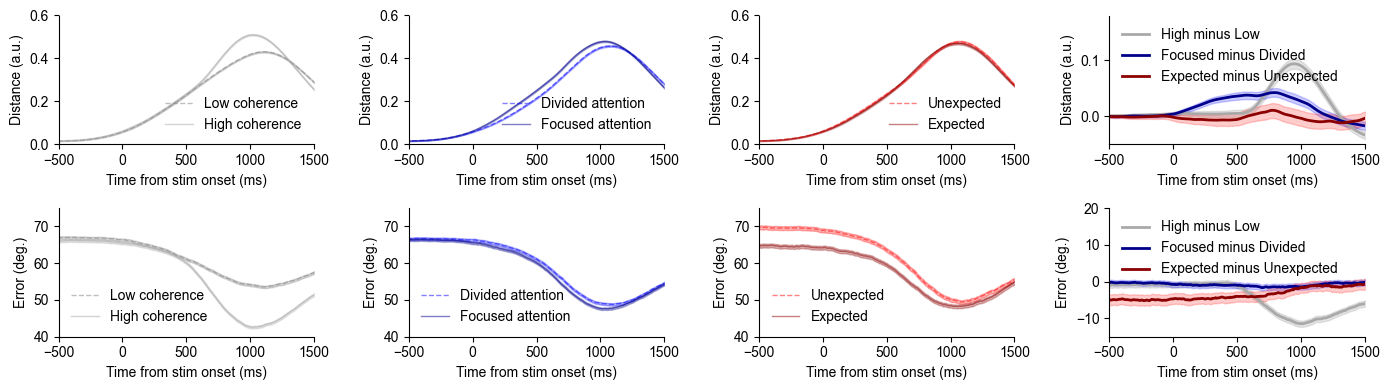

In [16]:
fig, ax = plt.subplots(2, 4, figsize=(14, 4), dpi=100, sharex=False)
# Create a 2-row x 4-column figure

alpha = 0.2  # For the fill transparency in difference plots

# ----- Top Row: Distance (d) Plots -----

# Define the d conditions in the same order as before:
# [0] d_low, [1] d_high, [2] d_divided, [3] d_focused, [4] d_unexpected, [5] d_expected
vals_d = [d_low, d_high, d_divided, d_focused, d_unexpected, d_expected]

# 1. Coherence: Plot d_low and d_high on ax[0,0]
ax_d_coh = ax[0, 0]
for i in [0, 1]:
    mean_val = np.nanmean(vals_d[i], axis=0)
    sem_val = np.nanstd(vals_d[i], axis=0) / np.sqrt(vals_d[i].shape[0])
    ax_d_coh.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_d_coh.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_d_coh.set_xlim(-500, 1500)
ax_d_coh.set_ylim(0, 0.6)
ax_d_coh.set_xlabel("Time from stim onset (ms)")
ax_d_coh.set_ylabel("Distance (a.u.)")
ax_d_coh.legend(loc='lower right', frameon=False)
ax_d_coh.spines['top'].set_visible(False)
ax_d_coh.spines['right'].set_visible(False)

# 2. Attention: Plot d_divided and d_focused on ax[0,1]
ax_d_att = ax[0, 1]
for i in [2, 3]:
    mean_val = np.nanmean(vals_d[i], axis=0)
    sem_val = np.nanstd(vals_d[i], axis=0) / np.sqrt(vals_d[i].shape[0])
    ax_d_att.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_d_att.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_d_att.set_xlim(-500, 1500)
ax_d_att.set_ylim(0, 0.6)
ax_d_att.set_xlabel("Time from stim onset (ms)")
ax_d_att.set_ylabel("Distance (a.u.)")
ax_d_att.legend(loc='lower right', frameon=False)
ax_d_att.spines['top'].set_visible(False)
ax_d_att.spines['right'].set_visible(False)

# 3. Expectation: Plot d_unexpected and d_expected on ax[0,2]
ax_d_exp = ax[0, 2]
for i in [4, 5]:
    mean_val = np.nanmean(vals_d[i], axis=0)
    sem_val = np.nanstd(vals_d[i], axis=0) / np.sqrt(vals_d[i].shape[0])
    ax_d_exp.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_d_exp.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_d_exp.set_xlim(-500, 1500)
ax_d_exp.set_ylim(0, 0.6)
ax_d_exp.set_xlabel("Time from stim onset (ms)")
ax_d_exp.set_ylabel("Distance (a.u.)")
ax_d_exp.legend(loc='lower right', frameon=False)
ax_d_exp.spines['top'].set_visible(False)
ax_d_exp.spines['right'].set_visible(False)

# 4. Differences for d on ax[0,3]
ax_d_diff = ax[0, 3]
# Coherence difference
ax_d_diff.plot(xaxis, d_high.mean(axis=0) - d_low.mean(axis=0),
               label='High minus Low', color='darkgray', linewidth=2)
ax_d_diff.fill_between(xaxis, diff_CI_coh[:, 0], diff_CI_coh[:, 1],
                       color='gray', alpha=alpha)
# Attention difference
ax_d_diff.plot(xaxis, d_focused.mean(axis=0) - d_divided.mean(axis=0),
               label='Focused minus Divided', color='darkblue', linewidth=2)
ax_d_diff.fill_between(xaxis, diff_CI_att[:, 0], diff_CI_att[:, 1],
                       color='blue', alpha=alpha)
# Expectation difference
ax_d_diff.plot(xaxis, d_expected.mean(axis=0) - d_unexpected.mean(axis=0),
               label='Expected minus Unexpected', color='darkred', linewidth=2)
ax_d_diff.fill_between(xaxis, diff_CI_exp[:, 0], diff_CI_exp[:, 1],
                       color='red', alpha=alpha)
ax_d_diff.set_xlim(-500, 1500)
ax_d_diff.set_ylim(-0.05, 0.18)
ax_d_diff.set_xlabel("Time from stim onset (ms)")
ax_d_diff.set_ylabel("Distance (a.u.)")
ax_d_diff.legend(loc='upper left', frameon=False)
ax_d_diff.spines['top'].set_visible(False)
ax_d_diff.spines['right'].set_visible(False)

# ----- Bottom Row: Error (e) Plots -----

# Define the e conditions:
vals_e = [e_low, e_high, e_divided, e_focused, e_unexpected, e_expected]

# 1. Coherence: Plot e_low and e_high on ax[1,0]
ax_e_coh = ax[1, 0]
for i in [0, 1]:
    mean_val = np.nanmean(vals_e[i], axis=0)
    sem_val = np.nanstd(vals_e[i], axis=0) / np.sqrt(vals_e[i].shape[0])
    ax_e_coh.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_e_coh.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_e_coh.set_xlim(-500, 1500)
ax_e_coh.set_ylim(40, 75)
ax_e_coh.set_xlabel("Time from stim onset (ms)")
ax_e_coh.set_ylabel("Error (deg.)")
ax_e_coh.legend(loc='lower left', frameon=False)
ax_e_coh.spines['top'].set_visible(False)
ax_e_coh.spines['right'].set_visible(False)

# 2. Attention: Plot e_divided and e_focused on ax[1,1]
ax_e_att = ax[1, 1]
for i in [2, 3]:
    mean_val = np.nanmean(vals_e[i], axis=0)
    sem_val = np.nanstd(vals_e[i], axis=0) / np.sqrt(vals_e[i].shape[0])
    ax_e_att.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_e_att.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_e_att.set_xlim(-500, 1500)
ax_e_att.set_ylim(40, 75)
ax_e_att.set_xlabel("Time from stim onset (ms)")
ax_e_att.set_ylabel("Error (deg.)")
ax_e_att.legend(loc='lower left', frameon=False)
ax_e_att.spines['top'].set_visible(False)
ax_e_att.spines['right'].set_visible(False)

# 3. Expectation: Plot e_unexpected and e_expected on ax[1,2]
ax_e_exp = ax[1, 2]
for i in [4, 5]:
    mean_val = np.nanmean(vals_e[i], axis=0)
    sem_val = np.nanstd(vals_e[i], axis=0) / np.sqrt(vals_e[i].shape[0])
    ax_e_exp.plot(xaxis, mean_val, linestyle=linestyles[i], label=labels[i],
                  color=colors[i], alpha=0.5, linewidth=1)
    ax_e_exp.fill_between(xaxis, mean_val - sem_val, mean_val + sem_val,
                          color=colors[i], alpha=0.3)
ax_e_exp.set_xlim(-500, 1500)
ax_e_exp.set_ylim(40, 75)
ax_e_exp.set_xlabel("Time from stim onset (ms)")
ax_e_exp.set_ylabel("Error (deg.)")
ax_e_exp.legend(loc='lower left', frameon=False)
ax_e_exp.spines['top'].set_visible(False)
ax_e_exp.spines['right'].set_visible(False)

# 4. Differences for e on ax[1,3]
ax_e_diff = ax[1, 3]
# Coherence difference
ax_e_diff.plot(xaxis, e_high.mean(axis=0) - e_low.mean(axis=0),
               label='High minus Low', color='darkgray', linewidth=2)
ax_e_diff.fill_between(xaxis, diff_CI_coh_e[:, 0], diff_CI_coh_e[:, 1],
                       color='gray', alpha=alpha)
# Attention difference
ax_e_diff.plot(xaxis, e_focused.mean(axis=0) - e_divided.mean(axis=0),
               label='Focused minus Divided', color='darkblue', linewidth=2)
ax_e_diff.fill_between(xaxis, diff_CI_att_e[:, 0], diff_CI_att_e[:, 1],
                       color='blue', alpha=alpha)
# Expectation difference
ax_e_diff.plot(xaxis, e_expected.mean(axis=0) - e_unexpected.mean(axis=0),
               label='Expected minus Unexpected', color='darkred', linewidth=2)
ax_e_diff.fill_between(xaxis, diff_CI_exp_e[:, 0], diff_CI_exp_e[:, 1],
                       color='red', alpha=alpha)
ax_e_diff.set_xlim(-500, 1500)
ax_e_diff.set_ylim(-15, 20)
ax_e_diff.set_xlabel("Time from stim onset (ms)")
ax_e_diff.set_ylabel("Error (deg.)")
ax_e_diff.legend(loc='upper left', frameon=False)
ax_e_diff.spines['top'].set_visible(False)
ax_e_diff.spines['right'].set_visible(False)

plt.tight_layout()
# plt.show()
plt.savefig('traces.svg', format="svg", transparent=True)